In [3]:
import pandas as pd
import numpy as np
import glob
import os
import seaborn as sns
import matplotlib.pyplot as plt
import streamlit as st

In [4]:
csv_folder = r'C:\Users\ruchi\OneDrive\Documents\Python Hackathon May 2026\HUPA-UC Diabetes Dataset-20250820T010637Z-1-001\HUPA-UC Diabetes Dataset'
output_file = r"C:\Temporary\combined_df_data.csv"
output_file2 = r"C:\Temporary\dashboard_data.csv"

In [5]:
files = os.path.join(csv_folder, "T1DM_patient_sleep_demographics_with_race.csv")


df = pd.read_csv(files)
output_df = pd.read_csv(output_file)


In [6]:
combined_df = pd.merge(df,output_df,
    on='Patient_ID',
    how='left'
)

print(combined_df.head())
combined_df.to_csv(output_file2)    

  Patient_ID  Age Gender   Race  Average Sleep Duration (hrs)  \
0  HUPA0001P   34   Male  Other                           6.3   
1  HUPA0001P   34   Male  Other                           6.3   
2  HUPA0001P   34   Male  Other                           6.3   
3  HUPA0001P   34   Male  Other                           6.3   
4  HUPA0001P   34   Male  Other                           6.3   

   Sleep Quality (1-10)  % with Sleep Disturbances            TimeStamp  \
0                   4.5                         80  2018-06-13 18:40:00   
1                   4.5                         80  2018-06-13 18:45:00   
2                   4.5                         80  2018-06-13 18:50:00   
3                   4.5                         80  2018-06-13 18:55:00   
4                   4.5                         80  2018-06-13 19:00:00   

         Date      Time  Hour  Minutes  Blood_Glucose_mg_dl  \
0  2018-06-13  18:40:00    18       40                332.0   
1  2018-06-13  18:45:00    18   

 ## KPIs

## Average Blood Glucose
High value indicates poor diabetes control.

Measures overall glucose condition.

In [25]:
avg_glucose = combined_df['Blood_Glucose_mg_dl'].mean()

print(avg_glucose)


141.42505110094714


## Maximum Glucose Level
Purpose

Identifies peak hyperglycemia risk.

Shows highest dangerous glucose reading.

In [26]:
max_glucose = combined_df['Blood_Glucose_mg_dl'].max()

print(max_glucose)

444.0


## Hyperglycemia Percentage

Measures percentage of readings above safe limit.

Higher percentage = higher clinical risk.

In [27]:
hyper = (
    combined_df['Blood_Glucose_mg_dl'] > 300
).mean() * 100

print(hyper)

1.3620261674510006


## Sleep Duration vs Heart Rate
Lower sleep duration may elevate heart rate
Indicates physiological stress

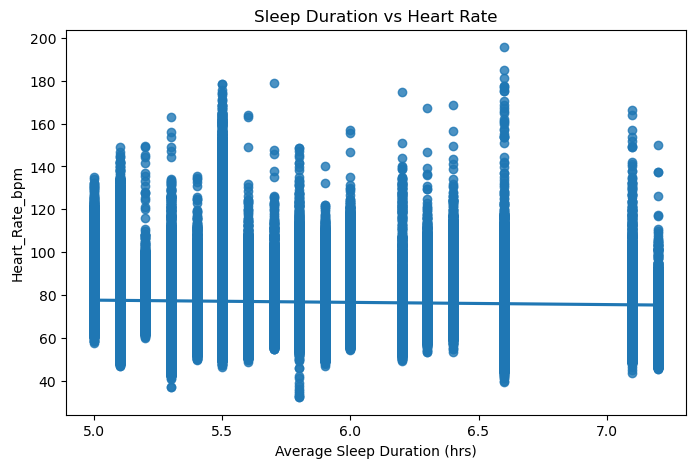

In [28]:
plt.figure(figsize=(8,5))

sns.regplot(
    x='Average Sleep Duration (hrs)',
    y='Heart_Rate_bpm',
    data=combined_df
)

plt.title('Sleep Duration vs Heart Rate')
plt.show()

## Heatmap of Combined Features
Shows relationships among:

Sleep,Glucose,Heart rate,Activity,Age

Index(['Patient_ID', 'Age', 'Gender', 'Race', 'Average Sleep Duration (hrs)',
       'Sleep Quality (1-10)', '% with Sleep Disturbances', 'TimeStamp',
       'Date', 'Time', 'Hour', 'Minutes', 'Blood_Glucose_mg_dl',
       'Basal_Insulin_Rate_Unit_hr', 'Bolus_Insulin_Dose_Units',
       'Carbohydrate_Intake_Grams', 'Step_count', 'Calories_burned',
       'Heart_Rate_bpm'],
      dtype='object')


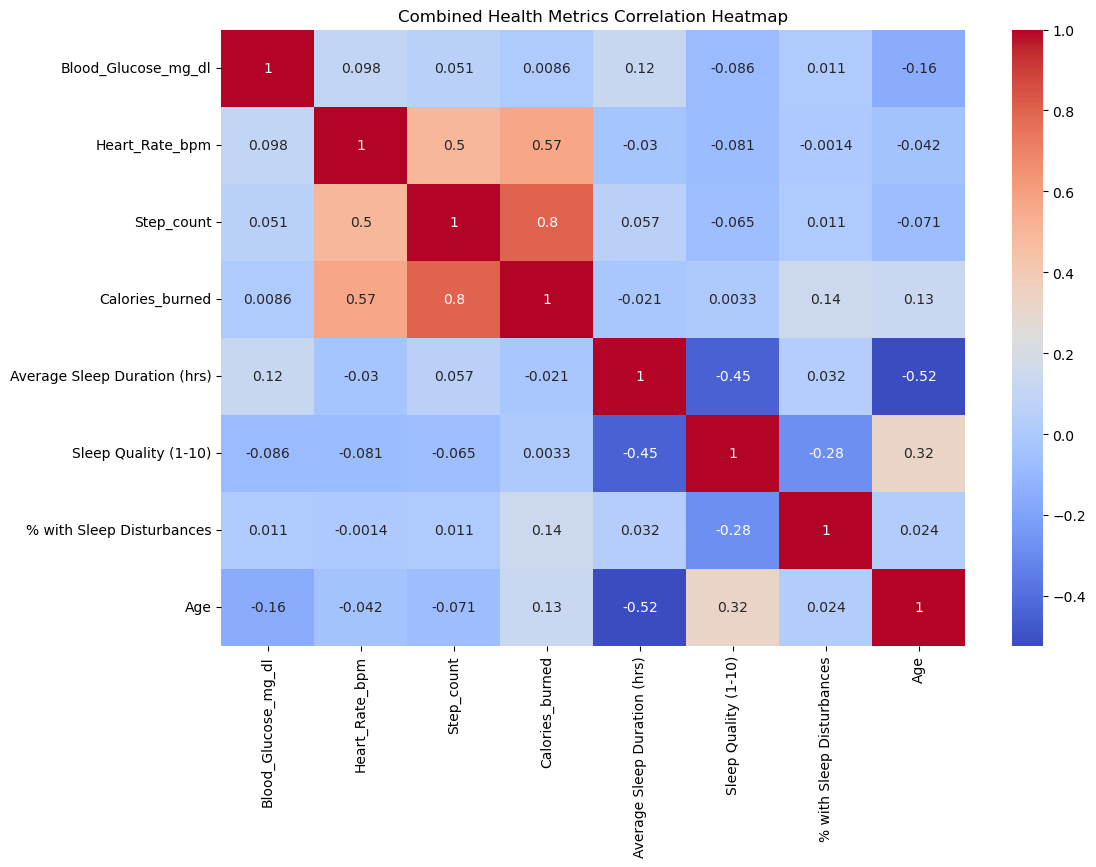

In [29]:
plt.figure(figsize=(12,8))
# Print combined_df.columns to verify column names
print(combined_df.columns)
sns.heatmap(
    combined_df[
        [
            'Blood_Glucose_mg_dl',
            'Heart_Rate_bpm',
            'Step_count',
            'Calories_burned',
            'Average Sleep Duration (hrs)',
            'Sleep Quality (1-10)',
            '% with Sleep Disturbances',
            'Age'
        ]
    ].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Combined Health Metrics Correlation Heatmap')

plt.show()

##### Insights
This is a correlation heatmap showing the relationship between different health metrics.
The values range from -1 to +1
+1 → strong positive relationship
-1 → strong negative relationship
0 → little or no relationship
The darker red colors indicate stronger positive correlations, while blue indicates negative correlations.
##### Step Count vs Calories Burned → Strong Positive Correlation (0.80)
This is the strongest relationship in the chart.
More steps generally lead to more calories burned.
Indicates physical activity directly impacts calorie expenditure.
Interpretation
People who are more active burn significantly more calories.

##### Heart Rate vs Calories Burned → Moderate Positive Correlation (0.57)
Higher heart rate is associated with more calories burned.
Common during exercise or physical activity.
Interpretation
As physical exertion increases, both heart rate and calorie burn increase.

##### Heart Rate vs Step Count → Moderate Positive Correlation (0.50)
More walking/activity tends to raise heart rate.
Interpretation
Physical movement contributes to cardiovascular activity.

##### Age vs Average Sleep Duration → Moderate Negative Correlation (-0.52)
This is one of the strongest negative relationships.
As age increases, average sleep duration tends to decrease.
Interpretation
Older individuals in this dataset may be sleeping fewer hours.

##### Average Sleep Duration vs Sleep Quality → Negative Correlation (-0.45)
Surprisingly, longer sleep duration is associated with lower sleep quality in this dataset.
Interpretation
People may be sleeping longer due to poor-quality or disturbed sleep rather than restful sleep.

##### Sleep Quality vs Age → Mild Positive Correlation (0.32)
Older participants show slightly better sleep quality scores.
Interpretation
Although older individuals sleep less, their reported sleep quality may be somewhat better.

##### Blood Glucose Relationships are Weak
Blood glucose has very low correlations with most variables:
Blood Glucose vs Heart Rate → 0.098
Blood Glucose vs Step Count → 0.051
Blood Glucose vs Calories Burned → 0.0086
Interpretation
Blood glucose levels in this dataset are not strongly influenced by activity or sleep metrics alone.

##### Sleep Disturbances Show Weak Relationships
Most correlations with “% with Sleep Disturbances” are close to zero.

Interpretation

Sleep disturbances may depend on additional factors not included in this dataset, such as:

Stress
Diet
Medication
Medical conditions


## Sleep Quality Distribution
Shows concentration of poor/good sleep scores.

Chart Type : Histogram + KDE Curve



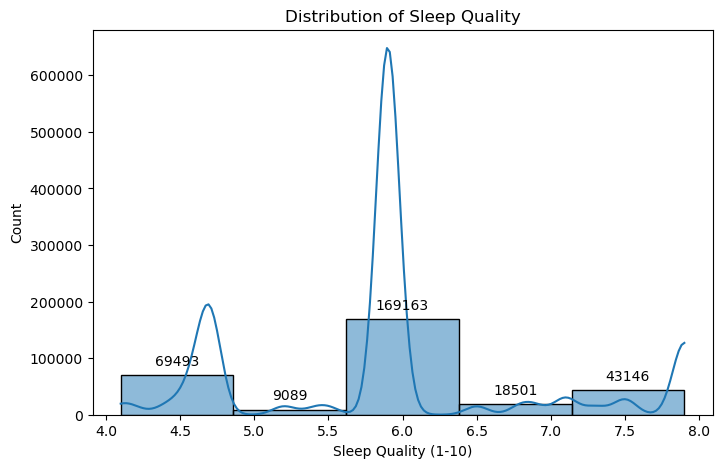

In [30]:
plt.figure(figsize=(8,5))

hist_plot = sns.histplot(
    combined_df['Sleep Quality (1-10)'],
    kde=True,
    bins=5
)

plt.title('Distribution of Sleep Quality')

for bar in hist_plot.patches:
    height = bar.get_height()
    if height > 0:
        hist_plot.annotate(
            f'{int(height)}',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 5),
            textcoords='offset points',
            ha='center',
            va='bottom'
        )

plt.show()

## Sleep Disturbance Comparison Chart
Shows population-level sleep patterns.

C:\Users\ruchi\AppData\Local\Temp\ipykernel_26748\4073064414.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(


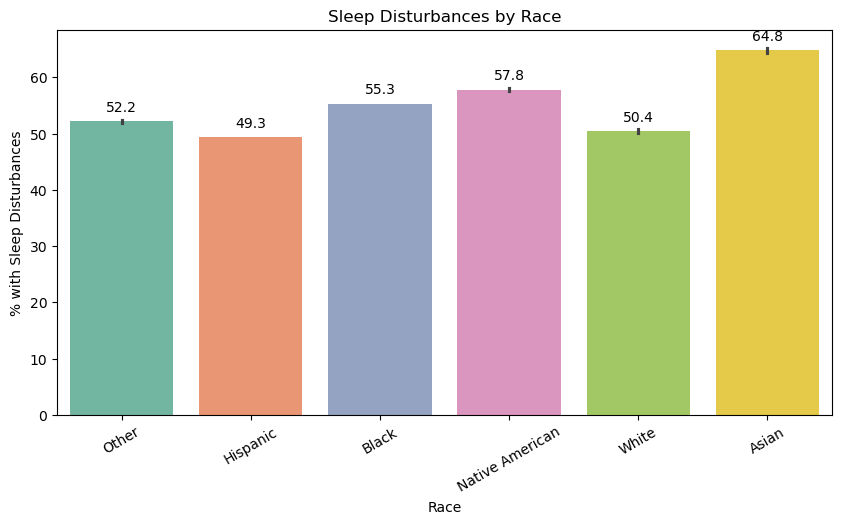

In [31]:
plt.figure(figsize=(10,5))

bar_plot = sns.barplot(
    x='Race',
    y='% with Sleep Disturbances',
    data=combined_df,
    palette='Set2'
)

plt.title('Sleep Disturbances by Race')

for bar in bar_plot.patches:
    height = bar.get_height()
    bar_plot.annotate(
        f'{height:.1f}',
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 5),
        textcoords='offset points',
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=30)

plt.show()